In [2]:
pkg load symbolic

    minus at line 42 column 5
gensol = (sym)

         ⎛      t           t       ⎞    
         ⎜     ℯ ⋅sin(t)   ℯ ⋅cos(t)⎟  -t
  y(t) = ⎜C₁ + ───────── - ─────────⎟⋅ℯ  
         ⎝         2           2    ⎠    



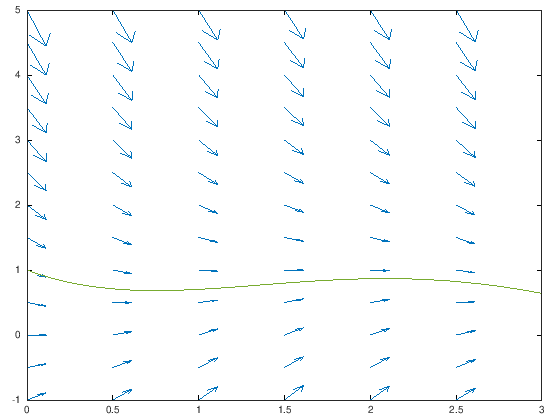

In [12]:
syms y(t) t ;
f=@(t,y) sin(t)-y ;
egyenlet=diff(y(t),t)==sin(t)-y ;
gensol=dsolve(egyenlet)
sol=dsolve(egyenlet,y(0)==1) ;
fsol=matlabFunction(rhs(sol)) ;
tb=0:0.5:3;
yb=-1:0.5:5;
[T,Y]=meshgrid(tb,yb);
dY=f(T,Y);
dT=ones(size(dY));
quiver(T,Y,dT,dY);
hold on;
xx=linspace(tb(1),tb(end));
plot(xx,fsol(xx));
axis([tb(1),tb(end),yb(1),yb(end)])

#### fixpont-iteráció
$$
y'=f(t,y)\ \ y(a)=b
$$
$$
y(t)=b+\int_a^t f(s,y(s))ds
$$
$$
y \to T(y), \ \text{ahol }\ T(y)(t)=b+\int_a^t f(s,y(s))ds
$$
$$
y_{n} \to y_{n+1}=T(y_n), \ \text{ahol }\ T(y_n)(t)=b+\int_a^t f(s,y_n(s))ds
$$

$$f(t,y)=\sin(t)-y,\ \ y_0(t)=1 $$
$$ y_1(t)=1+\int_0^t (\sin(s)-1) ds=
1-\cos(t)+1-t=2-t-\cos(t)$$ 
$$ y_2(t)=1+\int_0^t (\sin(s)-2+s+\cos(s)) ds= 
2-2t+\frac{t^2}{2}-\cos(t)+\sin(t)$$

$$ y_3(t)=1+\int_0^t (\sin(s)-2+2s-\frac{s^2}{2}+\cos(s)-\sin(s)) ds= 
1-2t+t^2-\frac{t^3}{6}+\sin(t)$$

$$ y_4(t)=1+\int_0^t (\sin(s)-1+2s-s^2+\frac{s^3}{6}-\sin(s)) ds= 
1-t+t^2-\frac{t^3}{3}+\frac{t^4}{24}$$


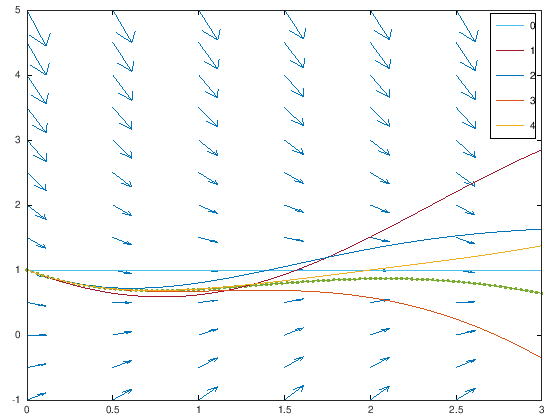

In [10]:
quiver(T,Y,dT,dY);
hold on;
xx=linspace(tb(1),tb(end));
plot(xx,fsol(xx),'.-');
uj0=@(t) ones(size(t));
plot(xx,uj0(xx),';0;');
uj1=@(t) 2-cos(t)-sin(t);
plot(xx,uj1(xx),';1;');
uj2=@(t) 2-2*t+1/2*t.^2-cos(t)+sin(t);
plot(xx,uj2(xx),';2;');
uj3=@(t) 1-2*t+t.^2-1/6*t.^3+sin(t);
plot(xx,uj3(xx),';3;');
uj4=@(t) 1-t+t.^2-1/3*t.^3+1/24*t.^4;
plot(xx,uj4(xx),';4;');

axis([tb(1),tb(end),yb(1),yb(end)])